In [1]:
!unzip -q sample_data/archive.zip -d dataset/


Resumo da quantidade de imagens:


Quantidade
Conjunto Classe                         
test     Covid-19                    300
         Emphysema                   250
         Normal                      300
         Pneumonia-Bacterial         300
         Pneumonia-Viral             300
         Tuberculosis                287
train    Covid-19                   2417
         Emphysema                  2050
         Normal                     2671
         Pneumonia-Bacterial        2400
         Pneumonia-Viral            2413
         Tuberculosis               2600
val      Covid-19                    300
         Emphysema                   250
         Normal                      300
         Pneumonia-Bacterial         300
         Pneumonia-Viral             300
         Tuberculosis                298

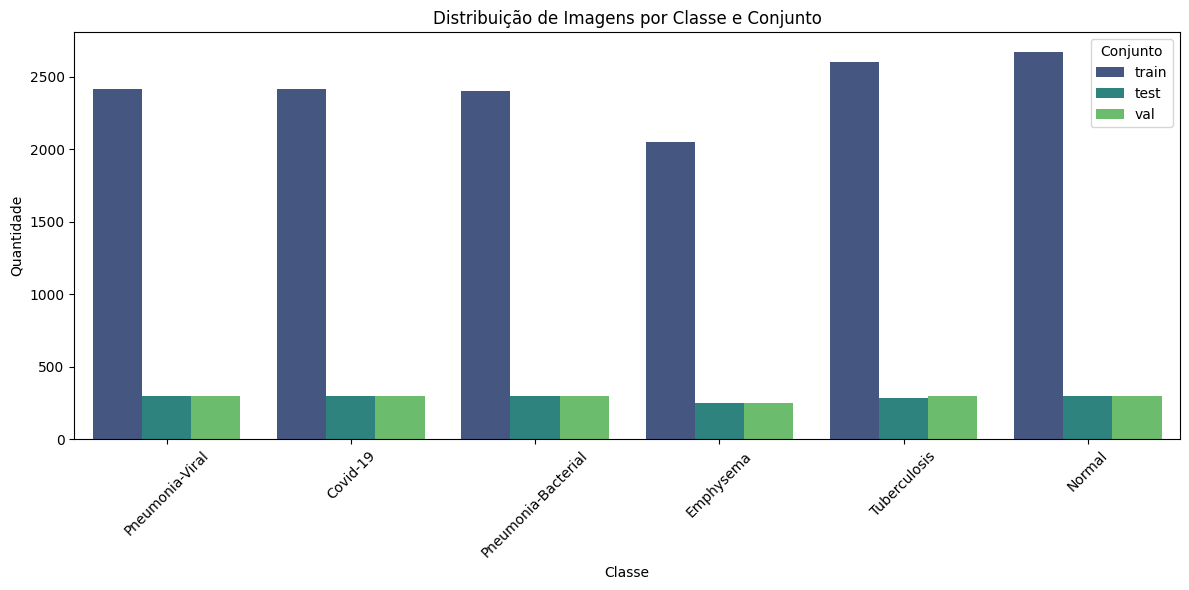

In [2]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Procura as pastas automaticamente
caminho_base = 'dataset'
dataset_path = None

for root, dirs, files in os.walk(caminho_base):
    if 'train' in dirs and 'test' in dirs:
        dataset_path = root
        break

if dataset_path is not None:
    pastas = ['train', 'test', 'val']
    dados = []

    for pasta in pastas:
        caminho_pasta = os.path.join(dataset_path, pasta)
        if os.path.exists(caminho_pasta):
            classes = os.listdir(caminho_pasta)
            for nome_classe in classes:
                caminho_classe = os.path.join(caminho_pasta, nome_classe)
                if os.path.isdir(caminho_classe):
                    dados.append({'Conjunto': pasta, 'Classe': nome_classe, 'Quantidade': len(os.listdir(caminho_classe))})

    df = pd.DataFrame(dados)
    print("Resumo da quantidade de imagens:")
    display(df.groupby(['Conjunto', 'Classe']).sum())

    plt.figure(figsize=(12, 6))
    sns.barplot(data=df, x='Classe', y='Quantidade', hue='Conjunto', palette='viridis')
    plt.title('Distribuição de Imagens por Classe e Conjunto')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [3]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

# Garantir que achamos as pastas
caminho_base = 'dataset'
dataset_path = None
for root, dirs, files in os.walk(caminho_base):
    if 'train' in dirs and 'val' in dirs:
        dataset_path = root
        break

train_dir = os.path.join(dataset_path, 'train')
val_dir = os.path.join(dataset_path, 'val')

IMG_HEIGHT, IMG_WIDTH, BATCH_SIZE = 224, 224, 32

# Data Augmentation (Aumento de Dados)
train_datagen = ImageDataGenerator(
    rescale=1./255, rotation_range=20, zoom_range=0.15,
    width_shift_range=0.1, height_shift_range=0.1, horizontal_flip=True
)
val_test_datagen = ImageDataGenerator(rescale=1./255)

print("--- Carregando Imagens ---")
train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=(IMG_HEIGHT, IMG_WIDTH), batch_size=BATCH_SIZE, class_mode='categorical'
)
val_generator = val_test_datagen.flow_from_directory(
    val_dir, target_size=(IMG_HEIGHT, IMG_WIDTH), batch_size=BATCH_SIZE, class_mode='categorical'
)

num_classes = len(train_generator.class_indices)

# Construção do Modelo CNN
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    BatchNormalization(), MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(), MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(), MaxPooling2D((2, 2)),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

--- Carregando Imagens ---
Found 14551 images belonging to 6 classes.
Found 1748 images belonging to 6 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    22,151,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,247,110 (84.87 MB)

 Trainable params: 22,246,662 (84.86 MB)

 Non-trainable params: 448 (1.75 KB)